<table align="left">
  <td>
    <a target="_blank" href="https://github.com/polyhedron-gdl/ml-for-finance-advanced/blob/main/2026/01-notebooks/06-encoder-decoder-translation-with-keras.ipynb">
        <img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

# Encoder-Decoder Translation with Keras

This notebook is a revised version of the original educational Spanish-to-English encoder-decoder example.

This version uses **all valid sentence pairs available in the file** instead of selecting only the original slice of the dataset. After cleaning, the available examples are randomly split into:

- **80% training set**;
- **10% validation set**;
- **10% test set**.

The goal is not to build a production translation system, but to make the experiment more methodologically correct and more useful for teaching.

## Implemented improvements

1. The Spanish input is no longer reshaped to `(samples, timesteps, 1)`, because the `Embedding` layer expects integer token IDs with shape `(samples, timesteps)`.
2. The full available dataset is split into training, validation, and test sets.
3. Final evaluation is performed on the held-out test set.
4. A padding-aware accuracy metric is added, so that padding tokens do not artificially inflate performance.
5. Several held-out test translations are printed for qualitative inspection.
6. The trained model and tokenizers are saved.
7. Early stopping and model checkpointing are used.
8. `<start>` and `<end>` tokens are added to the English target sentences.


## 1. Imports and reproducibility settings

We use TensorFlow/Keras for the neural network, NumPy for array handling, and Python's standard `pickle` module to save the tokenizers.


In [2]:
import os
import json
import pickle
import random
import string
from pathlib import Path

import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Embedding, Dense, LSTM
from tensorflow.keras.layers import RepeatVector, TimeDistributed, Activation
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Reproducibility.
# Notice that perfect reproducibility can still depend on hardware, GPU kernels, and TensorFlow settings.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Imports completed.")

Imports completed.


## 2. Configuration

The notebook expects the same translation file used in the original version: `./data/spa.txt`.

The file is usually tab-separated. In many versions of the dataset, each row contains at least two columns:

```text
English sentence 	 Spanish sentence
```

Some files may contain additional attribution columns. The code below uses only the first two columns.

Unlike the previous version, this notebook does **not** select a fixed slice such as `pairs[1000:80000]`. It uses all valid pairs found in the file.


In [3]:
# Path to the bilingual translation file.
DATA_PATH = Path("./data/spa.txt")

# Use all valid pairs available in the file.
# Set this to an integer only if you want a smaller classroom demonstration.
MAX_PAIRS = None

# Dataset split proportions.
# With VAL_SIZE = 0.10 and TEST_SIZE = 0.10, the remaining 80% is used for training.
# The final test set is used only once, after training.
VAL_SIZE = 0.10
TEST_SIZE = 0.10

# Training hyperparameters.
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3

# Model hyperparameters.
EMBEDDING_DIM = 128
LATENT_DIM = 64
DROPOUT_RATE = 0.20

# Special tokens for the target language.
START_TOKEN = "<start>"
END_TOKEN = "<end>"
EMPTY_TOKEN = "<empty>"
UNK_TOKEN = "<unk>"

# Directory where trained artifacts will be saved.
# We use a different directory to avoid overwriting the artifacts from the smaller-dataset notebook.
ARTIFACT_DIR = Path("./saved_translation_model_all_samples")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration completed.")


Configuration completed.


## 3. Load and parse the raw data

The next cell loads the raw file, splits it into rows, and keeps only valid English-Spanish pairs.


In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Please make sure that the Spanish-English file is available at this path."
    )

with DATA_PATH.open("r", encoding="utf-8") as translation_file:
    raw_data = translation_file.read().splitlines()

# Split rows by tab and retain only rows with at least two columns.
raw_pairs = []
for row in raw_data:
    parts = row.split("	")
    if len(parts) >= 2:
        english = parts[0].strip()
        spanish = parts[1].strip()
        if english and spanish:
            raw_pairs.append((english, spanish))

print(f"Total valid pairs in file: {len(raw_pairs):,}")

# Use all available valid pairs unless MAX_PAIRS is explicitly set.
if MAX_PAIRS is not None:
    raw_pairs = raw_pairs[:MAX_PAIRS]

print(f"Pairs used in this notebook: {len(raw_pairs):,}")
print("Example pair:")
print(raw_pairs[0])


Total valid pairs in file: 140,868
Pairs used in this notebook: 140,868
Example pair:
('Go.', 'Ve.')


## 4. Text cleaning

We keep the cleaning function intentionally simple, as in the original notebook.

The main difference is that we add `<start>` and `<end>` tokens to the English target after cleaning. These tokens should not be removed by punctuation cleaning.


In [5]:
def clean_sentence(sentence: str) -> str:
    """
    Lowercase a sentence and remove punctuation.

    This is a simple educational preprocessing function.
    For real translation systems, punctuation should usually be preserved or handled more carefully.
    """
    sentence = sentence.lower().strip()

    # Remove standard punctuation and Spanish inverted punctuation marks.
    punctuation_to_remove = string.punctuation + "¡" + "¿"
    sentence = sentence.translate(str.maketrans("", "", punctuation_to_remove))

    # Normalize repeated spaces.
    sentence = " ".join(sentence.split())
    return sentence


def add_start_end_tokens(sentence: str) -> str:
    """
    Add explicit sequence boundary tokens to a target-language sentence.
    """
    return f"{START_TOKEN} {sentence} {END_TOKEN}"


spanish_sentences = []
english_sentences = []
english_targets = []

for english_raw, spanish_raw in raw_pairs:
    english_clean = clean_sentence(english_raw)
    spanish_clean = clean_sentence(spanish_raw)

    # Keep only non-empty pairs after cleaning.
    if english_clean and spanish_clean:
        spanish_sentences.append(spanish_clean)
        english_sentences.append(english_clean)
        english_targets.append(add_start_end_tokens(english_clean))

print(f"Clean pairs retained: {len(spanish_sentences):,}")
print("Spanish example:", spanish_sentences[0])
print("English target example:", english_targets[0])


Clean pairs retained: 140,868
Spanish example: ve
English target example: <start> go <end>


## 5. Train-validation-test split

The original notebook trained and evaluated on the same data. Here we create three separate subsets from the full cleaned dataset:

- **training set**: 80% of the available examples, used to fit the model weights;
- **validation set**: 10% of the available examples, used during training for early stopping and checkpointing;
- **test set**: 10% of the available examples, used only after training for final evaluation.

The split is randomized with a fixed seed for reproducibility.

The tokenizers are fitted only on the training set. This avoids leaking vocabulary information from validation and test sets into the training process.


In [6]:
def split_indices(n_samples: int, val_size: float, test_size: float, seed: int = 42):
    """
    Create randomized train, validation, and test indices.
    """
    if val_size < 0 or test_size < 0 or val_size + test_size >= 1:
        raise ValueError("val_size and test_size must be non-negative and sum to less than 1.")

    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)

    n_test = int(round(n_samples * test_size))
    n_val = int(round(n_samples * val_size))

    test_idx = indices[:n_test]
    val_idx = indices[n_test:n_test + n_val]
    train_idx = indices[n_test + n_val:]

    return train_idx, val_idx, test_idx


n_samples = len(spanish_sentences)
train_idx, val_idx, test_idx = split_indices(
    n_samples=n_samples,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    seed=RANDOM_SEED,
)

spanish_sentences = np.array(spanish_sentences, dtype=object)
english_sentences = np.array(english_sentences, dtype=object)
english_targets = np.array(english_targets, dtype=object)

spa_train_text = spanish_sentences[train_idx].tolist()
spa_val_text = spanish_sentences[val_idx].tolist()
spa_test_text = spanish_sentences[test_idx].tolist()

eng_train_text = english_targets[train_idx].tolist()
eng_val_text = english_targets[val_idx].tolist()
eng_test_text = english_targets[test_idx].tolist()

# Version without special tokens, useful for display.
eng_test_clean_text = english_sentences[test_idx].tolist()

print(f"Total cleaned examples: {n_samples:,}")
print(f"Training examples:      {len(spa_train_text):,} ({len(spa_train_text) / n_samples:.1%})")
print(f"Validation examples:    {len(spa_val_text):,} ({len(spa_val_text) / n_samples:.1%})")
print(f"Test examples:          {len(spa_test_text):,} ({len(spa_test_text) / n_samples:.1%})")


Total cleaned examples: 140,868
Training examples:      112,694 (80.0%)
Validation examples:    14,087 (10.0%)
Test examples:          14,087 (10.0%)


## 6. Tokenization

We use one tokenizer for Spanish and one tokenizer for English.

Because tokenizers are fitted only on the training set, words appearing only in validation or test data will be mapped to `<unk>`.


In [7]:
def create_tokenizer(texts, oov_token=UNK_TOKEN):
    """
    Create and fit a Keras tokenizer.

    The oov_token handles words that were not observed in the training set.
    """
    tokenizer = Tokenizer(oov_token=oov_token)
    tokenizer.fit_on_texts(texts)
    return tokenizer


spa_text_tokenizer = create_tokenizer(spa_train_text)
eng_text_tokenizer = create_tokenizer(eng_train_text)

spanish_vocab = len(spa_text_tokenizer.word_index) + 1
english_vocab = len(eng_text_tokenizer.word_index) + 1

print(f"Spanish vocabulary size: {spanish_vocab:,}")
print(f"English vocabulary size: {english_vocab:,}")

print("English special-token indices:")
print("<unk>   ->", eng_text_tokenizer.word_index.get(UNK_TOKEN))
print("<start> ->", eng_text_tokenizer.word_index.get(START_TOKEN))
print("<end>   ->", eng_text_tokenizer.word_index.get(END_TOKEN))


Spanish vocabulary size: 25,831
English vocabulary size: 13,464
English special-token indices:
<unk>   -> 1
<start> -> None
<end>   -> None


## 7. Convert text to padded integer sequences

The Spanish input must have shape:

```python
(samples, max_spanish_len)
```

This is the correct shape for a Keras `Embedding` layer.

The English target has shape:

```python
(samples, max_english_len, 1)
```

This shape is convenient when using `sparse_categorical_crossentropy`, because each time step contains one integer class label.


In [8]:
# Convert training text to integer sequences.
spa_train_seq = spa_text_tokenizer.texts_to_sequences(spa_train_text)
eng_train_seq = eng_text_tokenizer.texts_to_sequences(eng_train_text)

# Define maximum lengths from the training set only.
max_spanish_len = max(len(seq) for seq in spa_train_seq)
max_english_len = max(len(seq) for seq in eng_train_seq)

print(f"Maximum Spanish input length: {max_spanish_len}")
print(f"Maximum English target length, including <start>/<end>: {max_english_len}")


def encode_and_pad(texts, tokenizer, max_len):
    """
    Convert a list of texts into padded integer sequences.
    """
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(
        sequences,
        maxlen=max_len,
        padding="post",
        truncating="post",
    )
    return padded


# Spanish inputs: keep 2D shape (samples, timesteps).
X_train = encode_and_pad(spa_train_text, spa_text_tokenizer, max_spanish_len)
X_val = encode_and_pad(spa_val_text, spa_text_tokenizer, max_spanish_len)
X_test = encode_and_pad(spa_test_text, spa_text_tokenizer, max_spanish_len)

# English targets: reshape to 3D shape (samples, timesteps, 1).
y_train = encode_and_pad(eng_train_text, eng_text_tokenizer, max_english_len)
y_val = encode_and_pad(eng_val_text, eng_text_tokenizer, max_english_len)
y_test = encode_and_pad(eng_test_text, eng_text_tokenizer, max_english_len)

y_train = y_train.reshape(y_train.shape[0], y_train.shape[1], 1)
y_val = y_val.reshape(y_val.shape[0], y_val.shape[1], 1)
y_test = y_test.reshape(y_test.shape[0], y_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:  ", X_val.shape)
print("y_val shape:  ", y_val.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)


Maximum Spanish input length: 68
Maximum English target length, including <start>/<end>: 72
X_train shape: (112694, 68)
y_train shape: (112694, 72, 1)
X_val shape:   (14087, 68)
y_val shape:   (14087, 72, 1)
X_test shape:  (14087, 68)
y_test shape:  (14087, 72, 1)


## 8. Padding-aware accuracy

The standard Keras accuracy treats padding tokens as ordinary tokens. This can be misleading because many target positions may simply be padding.

The custom metric below ignores positions where the true target token is `0`, the padding index.


In [9]:
def padding_aware_accuracy(y_true, y_pred):
    """
    Token-level accuracy computed only on non-padding target positions.

    Parameters
    ----------
    y_true:
        Tensor with true target token IDs. Expected shape: (batch, timesteps, 1)
        or (batch, timesteps).

    y_pred:
        Tensor with predicted token probabilities. Expected shape:
        (batch, timesteps, vocabulary_size).

    Returns
    -------
    Accuracy over non-padding positions only.
    """
    # Remove the final singleton dimension if present.
    if len(y_true.shape) == 3:
        y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.cast(y_true, tf.int64)
    y_pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int64)

    # Padding positions are where y_true == 0.
    mask = tf.not_equal(y_true, 0)

    matches = tf.equal(y_true, y_pred_ids)
    matches = tf.logical_and(matches, mask)

    matches = tf.cast(matches, tf.float32)
    mask = tf.cast(mask, tf.float32)

    return tf.math.divide_no_nan(tf.reduce_sum(matches), tf.reduce_sum(mask))


print("Custom metric defined.")


Custom metric defined.


## 9. Build the encoder-decoder model

This remains close to the original architecture:

```text
Spanish tokens -> Embedding -> LSTM encoder -> RepeatVector -> LSTM decoder -> Dense softmax
```

The decoder is still simplified: it does not yet use teacher forcing. That would be the next methodological upgrade after this notebook.


In [10]:
# Input shape is 2D at runtime: (batch_size, max_spanish_len).
# Therefore each single example has shape (max_spanish_len,).
input_sequence = Input(shape=(max_spanish_len,), name="spanish_input")

# The Embedding layer maps integer token IDs into dense vectors.
# mask_zero=True tells the LSTM to ignore Spanish padding tokens.
embedding = Embedding(
    input_dim=spanish_vocab,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="spanish_embedding",
)(input_sequence)

# Encoder: compress the Spanish sentence into a single latent vector.
encoder = LSTM(
    LATENT_DIM,
    return_sequences=False,
    name="encoder_lstm",
)(embedding)

# Repeat the encoder vector once for each English output time step.
r_vec = RepeatVector(max_english_len, name="repeat_context_vector")(encoder)

# Decoder: generate a sequence of hidden states.
decoder = LSTM(
    LATENT_DIM,
    return_sequences=True,
    dropout=DROPOUT_RATE,
    name="decoder_lstm",
)(r_vec)

# At each output time step, predict a distribution over the English vocabulary.
logits = TimeDistributed(
    Dense(english_vocab),
    name="word_logits",
)(decoder)

output = Activation("softmax", name="word_probabilities")(logits)

enc_dec_model = Model(input_sequence, output, name="improved_lstm_encoder_decoder")

enc_dec_model.compile(
    loss=sparse_categorical_crossentropy,
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy", padding_aware_accuracy],
)

enc_dec_model.summary()


Model: "improved_lstm_encoder_decoder"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Param ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃     # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━┩
│ spanish_in… │ (None,    │     0 │ -          │
│ (InputLaye… │ 68)       │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ spanish_em… │ (None,    │ 3,30… │ spanish_i… │
│ (Embedding) │ 68, 128)  │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ not_equal   │ (None,    │     0 │ spanish_i… │
│ (NotEqual)  │ 68)       │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ encoder_ls… │ (None,    │ 49,4… │ spanish_e… │
│ (LSTM)      │ 64)       │       │ not_equal… │
├─────────────┼───────────┼───────┼────────────┤
│ repeat_con… │ (None,    │     0 │ encoder_l… │
│ (RepeatVec… │ 72, 64)   │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ decoder_ls… │ (None,    │ 33,0… │ repeat_co… │
│ (LSTM)      │ 72, 64)   │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ word_logits │ (None,    │ 875,… │ decoder_l… │
│ (TimeDistr… │ 72,       │       │            │
│             │ 13464)    │       │            │
├─────────────┼───────────┼───────┼────────────┤
│ word_proba… │ (None,    │     0 │ word_logi… │
│ (Activatio… │ 72,       │       │            │
│             │ 13464)    │       │            │
└─────────────┴───────────┴───────┴────────────┘

 Total params: 4,263,960 (16.27 MB)

 Trainable params: 4,263,960 (16.27 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Early stopping and checkpointing

Early stopping prevents unnecessary training once validation loss stops improving.

Model checkpointing saves the best model observed during training, not simply the model from the final epoch.


In [11]:
best_model_path = ARTIFACT_DIR / "best_encoder_decoder.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=str(best_model_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

print("Callbacks ready.")
print("Best model will be saved to:", best_model_path)

Callbacks ready.
Best model will be saved to: saved_translation_model_all_samples\best_encoder_decoder.keras


## 11. Train the model

The validation set is used during training. The test set is not used here.

Because this version uses all available valid pairs, training may take noticeably longer than in the smaller-dataset version.


In [11]:
history = enc_dec_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/50
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8864 - loss: 1.6983 - padding_aware_accuracy: 0.0698
Epoch 1: val_loss improved from inf to 0.57530, saving model to saved_translation_model_all_samples\best_encoder_decoder.keras
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2070s 1s/step - accuracy: 0.8864 - loss: 1.6978 - padding_aware_accuracy: 0.0698 - val_accuracy: 0.9103 - val_loss: 0.5753 - val_padding_aware_accuracy: 0.2417
Epoch 2/50
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9101 - loss: 0.5723 - padding_aware_accuracy: 0.2430
Epoch 2: val_loss improved from 0.57530 to 0.55207, saving model to saved_translation_model_all_samples\best_encoder_decoder.keras
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2037s 1s/step - accuracy: 0.9101 - loss: 0.5723 - padding_aware_accuracy: 0.2430 - val_accuracy: 0.9125 - val_loss: 0.5521 - val_padding_aware_accuracy: 0.2483
Epoch 3/50
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9133 - loss: 0.5428 - padding_aware_accuracy: 0.2699


1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2381s 1s/step - accuracy: 0.9443 - loss: 0.2500 - padding_aware_accuracy: 0.5313 - val_accuracy: 0.9359 - val_loss: 0.3318 - val_padding_aware_accuracy: 0.4830
Epoch 34/50
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9447 - loss: 0.2478 - padding_aware_accuracy: 0.5345
Epoch 34: val_loss improved from 0.33179 to 0.33082, saving model to saved_translation_model_all_samples\best_encoder_decoder.keras
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2328s 1s/step - accuracy: 0.9447 - loss: 0.2478 - padding_aware_accuracy: 0.5345 - val_accuracy: 0.9362 - val_loss: 0.3308 - val_padding_aware_accuracy: 0.4850
Epoch 35/50
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9450 - loss: 0.2455 - padding_aware_accuracy: 0.5375
Epoch 35: val_loss did not improve from 0.33082
1761/1761 ━━━━━━━━━━━━━━━━━━━━ 2208s 1s/step - accuracy: 0.9450 - loss: 0.2455 - padding_aware_accuracy: 0.5375 - val_accuracy: 0.9357 - val_loss: 0.3318 - val_padding_aware_accuracy: 0.4867
Epoch

## 12. Inspect the training history

The following cell plots both the standard accuracy and the padding-aware accuracy.

In many translation examples, the standard accuracy can look overly optimistic because predicting padding positions correctly is easy.


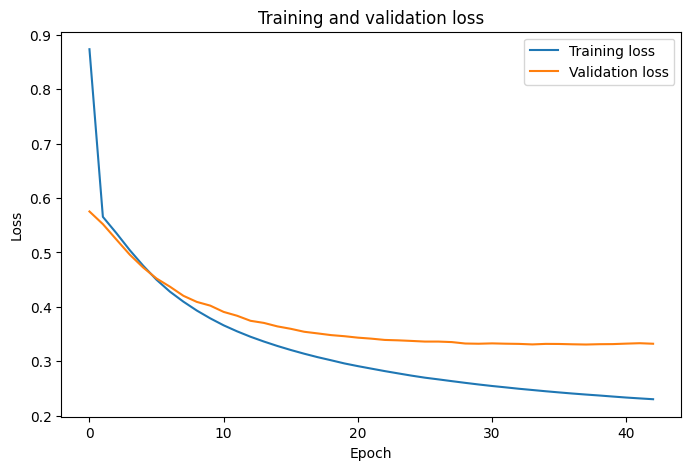

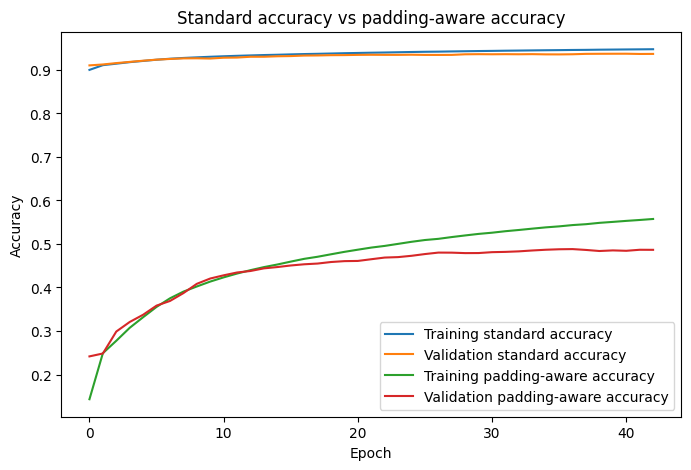

In [12]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(8, 5))
plt.plot(history_dict["loss"], label="Training loss")
plt.plot(history_dict["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_dict["accuracy"], label="Training standard accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation standard accuracy")
plt.plot(history_dict["padding_aware_accuracy"], label="Training padding-aware accuracy")
plt.plot(history_dict["val_padding_aware_accuracy"], label="Validation padding-aware accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Standard accuracy vs padding-aware accuracy")
plt.legend()
plt.show()


## 13. Final evaluation on the held-out test set

This is the first time the test set is used.


In [12]:
# Load the best saved model if it exists.
# We pass the custom metric so that Keras can deserialize the model correctly.
if best_model_path.exists():
    enc_dec_model = load_model(
        best_model_path,
        custom_objects={"padding_aware_accuracy": padding_aware_accuracy},
    )
    print("Loaded best checkpoint:", best_model_path)

# Evaluate only on the held-out test set.
test_results = enc_dec_model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    return_dict=True,
)

print("Test results:")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")


Loaded best checkpoint: saved_translation_model_all_samples\best_encoder_decoder.keras
221/221 ━━━━━━━━━━━━━━━━━━━━ 149s 658ms/step - accuracy: 0.9363 - loss: 0.3318 - padding_aware_accuracy: 0.4825
Test results:
accuracy: 0.9365
loss: 0.3315
padding_aware_accuracy: 0.4839


## 14. Decode predictions into sentences

The model outputs a probability distribution over the English vocabulary at each output position. We convert each distribution into the most likely token using `argmax`.


In [14]:
def build_index_to_word(tokenizer):
    """
    Build a reverse dictionary from token ID to word.
    """
    index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}
    index_to_word[0] = EMPTY_TOKEN
    return index_to_word


eng_index_to_word = build_index_to_word(eng_text_tokenizer)


def token_ids_to_sentence(token_ids, index_to_word, skip_special_tokens=True):
    """
    Convert a sequence of token IDs into a readable sentence.
    """
    words = []

    for token_id in token_ids:
        word = index_to_word.get(int(token_id), UNK_TOKEN)

        if skip_special_tokens:
            if word in {EMPTY_TOKEN, START_TOKEN}:
                continue
            if word == END_TOKEN:
                break

        words.append(word)

    return " ".join(words)


def logits_to_sentence(logits, tokenizer):
    """
    Convert model output probabilities into a decoded sentence.
    """
    index_to_word = build_index_to_word(tokenizer)
    predicted_token_ids = np.argmax(logits, axis=-1)
    return token_ids_to_sentence(predicted_token_ids, index_to_word)


print("Decoding utilities ready.")

Decoding utilities ready.


## 15. Print several test-set translation examples

These examples come from the held-out test set, not from the training set.


In [16]:
def show_translation_examples(model, X, source_texts, target_texts, tokenizer, n_examples=10, seed=42):
    """
    Print random translation examples from a given dataset split.
    """
    rng = np.random.default_rng(seed)
    n_examples = min(n_examples, len(X))
    selected_indices = rng.choice(len(X), size=n_examples, replace=False)

    predictions = model.predict(X[selected_indices], verbose=0)

    for display_number, idx in enumerate(selected_indices, start=1):
        predicted_sentence = logits_to_sentence(predictions[display_number - 1], tokenizer)

        print("=" * 80)
        print(f"Example {display_number}")
        print("Spanish input:      ", source_texts[idx])
        print("True English:       ", target_texts[idx])
        print("Predicted English:  ", predicted_sentence)


show_translation_examples(
    model=enc_dec_model,
    X=X_test,
    source_texts=spa_test_text,
    target_texts=eng_test_clean_text,
    tokenizer=eng_text_tokenizer,
    n_examples=10,
    seed=RANDOM_SEED,
)

Example 1
Spanish input:       todo tiene un propósito
True English:        everything has a purpose
Predicted English:   start he has a problem end
Example 2
Spanish input:       deberías estar en casa
True English:        you should be home
Predicted English:   start you should stay home home end
Example 3
Spanish input:       quiero estar sola
True English:        i want to be alone
Predicted English:   start i want to be alone end
Example 4
Spanish input:       no hay razones para creerlo
True English:        theres no reason to believe it
Predicted English:   start there is no reason to tom end end
Example 5
Spanish input:       cuándo vuelve tu hermana de trabajar no sé pero creo que va a llegar a casa un par de minutos antes de mí
True English:        when does your sister come back from work i dont know but i think shell arrive at home a few minutes before me
Predicted English:   start when day i i a a days i i i i i i i i end end end
Example 6
Spanish input:       te lo puedo 

## 16. Translate a new Spanish sentence

This helper function applies the same cleaning, tokenization, and padding steps used during training.


In [17]:
def translate_spanish_sentence(sentence, model=enc_dec_model):
    """
    Translate one Spanish sentence using the trained model.
    """
    cleaned = clean_sentence(sentence)
    encoded = encode_and_pad([cleaned], spa_text_tokenizer, max_spanish_len)
    prediction = model.predict(encoded, verbose=0)[0]
    return logits_to_sentence(prediction, eng_text_tokenizer)


example_sentence = "me gusta aprender idiomas"

print("Spanish input:", example_sentence)
print("Predicted English:", translate_spanish_sentence(example_sentence))

Spanish input: me gusta aprender idiomas
Predicted English: start i like to learn languages


## 17. Save the final model, tokenizers, and configuration

The model and preprocessing objects must be saved together. Without the tokenizers and maximum sequence lengths, the trained model cannot be used correctly later.


In [18]:
final_model_path = ARTIFACT_DIR / "final_encoder_decoder.keras"
spanish_tokenizer_path = ARTIFACT_DIR / "spanish_tokenizer.pkl"
english_tokenizer_path = ARTIFACT_DIR / "english_tokenizer.pkl"
config_path = ARTIFACT_DIR / "translation_config.json"

# Save final model.
enc_dec_model.save(final_model_path)

# Save tokenizers.
with spanish_tokenizer_path.open("wb") as f:
    pickle.dump(spa_text_tokenizer, f)

with english_tokenizer_path.open("wb") as f:
    pickle.dump(eng_text_tokenizer, f)

# Save configuration needed at inference time.
config = {
    "max_spanish_len": max_spanish_len,
    "max_english_len": max_english_len,
    "spanish_vocab": spanish_vocab,
    "english_vocab": english_vocab,
    "start_token": START_TOKEN,
    "end_token": END_TOKEN,
    "empty_token": EMPTY_TOKEN,
    "unk_token": UNK_TOKEN,
}

with config_path.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts:")
print("Final model:       ", final_model_path)
print("Best checkpoint:   ", best_model_path)
print("Spanish tokenizer: ", spanish_tokenizer_path)
print("English tokenizer: ", english_tokenizer_path)
print("Configuration:     ", config_path)

Saved artifacts:
Final model:        saved_translation_model_all_samples\final_encoder_decoder.keras
Best checkpoint:    saved_translation_model_all_samples\best_encoder_decoder.keras
Spanish tokenizer:  saved_translation_model_all_samples\spanish_tokenizer.pkl
English tokenizer:  saved_translation_model_all_samples\english_tokenizer.pkl
Configuration:      saved_translation_model_all_samples\translation_config.json


## 18. Reloading the saved artifacts

This final cell demonstrates how the saved model and tokenizers can be reloaded in a future session.


In [19]:
# Example reload code.
# You can run this in a fresh notebook/session after training.

reloaded_model = load_model(
    final_model_path,
    custom_objects={"padding_aware_accuracy": padding_aware_accuracy},
)

with spanish_tokenizer_path.open("rb") as f:
    reloaded_spa_tokenizer = pickle.load(f)

with english_tokenizer_path.open("rb") as f:
    reloaded_eng_tokenizer = pickle.load(f)

with config_path.open("r", encoding="utf-8") as f:
    reloaded_config = json.load(f)

print("Reload completed.")
print(reloaded_config)


Reload completed.
{'max_spanish_len': 68, 'max_english_len': 72, 'spanish_vocab': 25831, 'english_vocab': 13464, 'start_token': '<start>', 'end_token': '<end>', 'empty_token': '<empty>', 'unk_token': '<unk>'}


## 19. What this notebook still does not do

This full-dataset version fixes the most immediate methodological problems in the original notebook and uses all available samples, but it is still a simple educational model.

The next natural upgrades would be:

- a proper teacher-forcing decoder;
- separate decoder inputs and decoder targets;
- attention;
- BLEU or chrF evaluation;
- a comparison with a Transformer-based model.
